# Phase 2 — Continual Learning Setup & Catastrophic Forgetting

**Paper:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## What this notebook does

1. Implements the **baseline CNN** from Zou et al. (2020) as described in the paper (Fig. 2)
2. Builds the **4-task continual learning split** (Table II)
3. Trains the model with **three replay strategies** for direct comparison:
   - **0% replay** — standard fine-tuning, no mitigation (`Std.` baseline)
   - **15% replay** — re-process 15% of previous tasks' data at each step
   - **30% replay** — re-process 30% of previous tasks' data at each step
4. Evaluates accuracy on all previous tasks after each training step
5. Plots a **unified comparison** of the three strategies — reproducing Fig. 4 (`Std.` rows)

## Expected outcome

Forgetting should decrease as replay percentage increases.  
This is the `Std. 0%`, `Std. 10%`, `Std. 30%` family from Fig. 4 of the paper  
(we use 15% instead of 10% — a small variation you can discuss in your thesis).

---

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Check for Apple Silicon GPU (MPS), then CUDA, then CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using device: CUDA (NVIDIA GPU)")
else:
    DEVICE = torch.device("cpu")
    print("Using device: CPU")

Using device: MPS (Apple Silicon GPU)


## 1. Configuration

All experiment parameters in one place — easy to tweak.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DATA_DIR = '../Data/Dataset_1/train'   # <-- update to your local path
TEST_DATA_DIR  = '../Data/Dataset_1/test'    # <-- update to your local path

# ── Data ──────────────────────────────────────────────────────────────────────
N_CHANNELS   = 6      # 6 if using only acc+gyr, 9 if magnitude channels are added
WINDOW_SIZE  = 128
VAL_SPLIT    = 0.15   # fraction of each task's training data held out for validation
RANDOM_SEED  = 27

# ── Training ──────────────────────────────────────────────────────────────────
# BUG FIX 1: 20 epochs is far too few to see meaningful forgetting vs learning.
# The first epoch with high LR completely overwrites Task 1 weights -> 0% instantly.
# Use 100 for fast experimentation, 400 to match the paper.
EPOCHS       = 50   # 100 fast | 400 paper-accurate
BATCH_SIZE   = 64
LR_INIT      = 1e-3   # starting learning rate
# BUG FIX 2: LR_DECAY=0.9 with 400 epochs -> LR=1e-3*0.9^400 ≈ 1e-21 (dead).
# 0.98^400 = 3e-4 which is a healthy final LR. Use 0.98 to match paper intent.
LR_DECAY     = 0.98  # per-epoch exponential decay — matches paper behaviour

# ── CL task split (Table II of the paper, 1-indexed labels) ───────────────────
TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}
N_CLASSES_TOTAL = 118   # total subjects across all tasks

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Load and prepare data

In [3]:
# ── Load test set (Phase 1 data) ──────────────────────────────────────────────
def load_test_data(data_dir):
    """Load the 6-channel IMU test set from .txt files."""
    channels = ['test_acc_x', 'test_acc_y', 'test_acc_z',
                'test_gyr_x', 'test_gyr_y', 'test_gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{ch}.txt') for ch in channels]
    X = np.stack(signals, axis=1).astype(np.float32)  # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_test.txt', dtype=int)
    return X, y

def load_train_data(data_dir):
    """Load the 6-channel IMU test set from .txt files."""
    channels = ['train_acc_x', 'train_acc_y', 'train_acc_z',
                'train_gyr_x', 'train_gyr_y', 'train_gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{ch}.txt') for ch in channels]
    X = np.stack(signals, axis=1).astype(np.float32)  # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_train.txt', dtype=int)
    return X, y

X_train, y_train = load_train_data(TRAIN_DATA_DIR)
print(f'Training set loaded: X={X_train.shape}, y={y_train.shape}')
X_test, y_test = load_test_data(TEST_DATA_DIR)
print(f'Test set loaded: X={X_test.shape}, y={y_test.shape}')


X_all, y_all = np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train, y_test], axis=0)
print(f'All data combined: X={X_all.shape}, y={y_all.shape}')

Training set loaded: X=(33104, 6, 128), y=(33104,)
Test set loaded: X=(3740, 6, 128), y=(3740,)
All data combined: X=(36844, 6, 128), y=(36844,)


In [4]:
# ── Normalize using ONLY training set statistics (NO LEAKAGE) ─────────────────
def normalize_channels(X_train, X_test):
    """
    Calculates mean and std ONLY on the training set, 
    then applies them to both train and test sets.
    """
    # 1. Calculate stats strictly on training data
    mean = X_train.mean(axis=(0, 2), keepdims=True)  # (1, C, 1)
    std  = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    
    # 2. Apply the SAME stats to both datasets
    X_train_norm = (X_train - mean) / std
    X_test_norm  = (X_test - mean) / std
    
    return X_train_norm, X_test_norm, mean, std

# Execute the proper normalization
X_train_norm, X_test_norm, ch_mean, ch_std = normalize_channels(X_train, X_test)

print(f'Normalized X_train: mean≈{X_train_norm.mean():.4f}, std≈{X_train_norm.std():.4f}')
# Note: X_test mean/std will not be exactly 0 and 1, which is completely normal and correct!
print(f'Normalized X_test:  mean≈{X_test_norm.mean():.4f}, std≈{X_test_norm.std():.4f}')

# ── Remap labels to 0-indexed (required by CrossEntropyLoss) ─────────────────
unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}

# Apply mapping separately
y_train_idx = np.array([label_to_idx[l] for l in y_train])
y_test_idx  = np.array([label_to_idx[l] for l in y_test])

print(f'Labels remapped: {y_train.min()}–{y_train.max()} → 0–{y_train_idx.max()}')

Normalized X_train: mean≈-0.0000, std≈1.0000
Normalized X_test:  mean≈0.0035, std≈0.9960
Labels remapped: 1–118 → 0–117


In [5]:
# ── Build per-task datasets with strict official test sets ───────────────────
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx, task_splits, val_split, seed):
    """
    Returns a dict of {task_name: {'train': TensorDataset, 'val': TensorDataset, 'test': TensorDataset}}
    Uses the official held-out test set for the 'test' split.
    """
    rng = torch.Generator().manual_seed(seed)
    task_data = {}

    for task_name, (lo, hi) in task_splits.items():
        # 1. Process Train and Val (from training data)
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t_tr  = torch.tensor(X_tr[mask_tr])
        y_t_tr  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        
        full_train_ds = TensorDataset(X_t_tr, y_t_tr)
        n_val   = max(1, int(len(full_train_ds) * val_split))
        n_train = len(full_train_ds) - n_val
        train_ds, val_ds = random_split(full_train_ds, [n_train, n_val], generator=rng)
        
        # 2. Process Test (strictly from official test data)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        X_t_te  = torch.tensor(X_te[mask_te])
        y_t_te  = torch.tensor(y_te_idx[mask_te], dtype=torch.long)
        test_ds = TensorDataset(X_t_te, y_t_te)

        task_data[task_name] = {
            'train': train_ds,
            'val':   val_ds,
            'test':  test_ds,
        }
        print(f'{task_name}: {n_train} train  |  {n_val} val  |  {len(X_t_te)} test')

    return task_data

# Execute the function with the separated data
task_data = make_task_datasets(
    X_train_norm, y_train, y_train_idx, 
    X_test_norm, y_test, y_test_idx, 
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)

Task 1: 7347 train  |  1296 val  |  975 test
Task 2: 7241 train  |  1277 val  |  962 test
Task 3: 6540 train  |  1153 val  |  871 test
Task 4: 7013 train  |  1237 val  |  932 test


## 3. The baseline CNN architecture

Reproducing Fig. 2 of the paper: four 1D-Conv → ReLU → MaxPool blocks, then Flatten → FC embedding → FC classifier.

The CDML layer (`m = sₖ ⊙ h`) sits between the embedding and the classifier — **it is not included here**. We add it in Phase 3.

In [6]:
class ConvBlock(nn.Module):
    """1D Conv → ReLU → MaxPool block."""
    def __init__(self, in_channels, out_channels, kernel_size=3, pool_size=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=pool_size),
        )

    def forward(self, x):
        return self.block(x)


class GaitCNN(nn.Module):
    """
    Baseline CNN from Zou et al. (2020) as used in Milani (2024).

    Architecture (Fig. 2, gray blocks):
      Input:  (batch, C, 128)
      Conv1:  32 filters, kernel 3, MaxPool 2  → (batch, 32, 64)
      Conv2:  64 filters, kernel 3, MaxPool 2  → (batch, 64, 32)
      Conv3: 128 filters, kernel 3, MaxPool 2  → (batch, 128, 16)
      Conv4: 128 filters, kernel 3, MaxPool 2  → (batch, 128, 8)
      Flatten → FC(1024)                        → h (embedding, 128-dim via FC)
      FC(n_classes) → Softmax                   → likelihood l

    Note: the CDML layer (m = sₖ ⊙ h) is inserted between embedding and
    classifier in Phase 3. Here we expose `embed()` so Phase 3 can hook in.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.n_classes = n_classes
        self.embed_dim = embed_dim

        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels,  32),
            ConvBlock(32,          64),
            ConvBlock(64,         128),
            ConvBlock(128,        128),
            nn.Flatten(),
        )
        # Compute flattened size dynamically
        dummy = torch.zeros(1, n_channels, WINDOW_SIZE)
        flat_size = self.feature_extractor(dummy).shape[1]

        self.embedding = nn.Linear(flat_size, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        """Return the 128-dim embedding h — used by CDML in Phase 3."""
        h = self.feature_extractor(x)
        h = self.embedding(h)
        return h  # shape: (batch, embed_dim)

    def forward(self, x):
        h = self.embed(x)
        return self.classifier(h)  # raw logits; CrossEntropyLoss handles softmax


# Quick sanity check
model = GaitCNN(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL).to(DEVICE)
dummy = torch.zeros(4, N_CHANNELS, WINDOW_SIZE).to(DEVICE)
out   = model(dummy)
print(f'Model output shape: {out.shape}  (expected: [4, {N_CLASSES_TOTAL}])')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Model output shape: torch.Size([4, 118])  (expected: [4, 118])
Total parameters: 227,222


## 4. Training utilities

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def build_replay_loader(current_train_ds, past_train_datasets,
                         replay_fraction, batch_size):
    """
    Build the DataLoader for one training step, optionally mixing in
    a random fraction of each previously-seen task's training data.

    Parameters
    ----------
    current_train_ds    : Dataset for the current task
    past_train_datasets : list of Datasets from all previous tasks
    replay_fraction     : float in [0, 1] — fraction of each past dataset to replay
    batch_size          : int

    Returns
    -------
    DataLoader mixing current + replayed data
    """
    if replay_fraction == 0.0 or len(past_train_datasets) == 0:
        return DataLoader(current_train_ds, batch_size=batch_size, shuffle=True)

    datasets_to_mix = [current_train_ds]
    for past_ds in past_train_datasets:
        n_replay = max(1, int(len(past_ds) * replay_fraction))
        # Random subset — different every call, ensuring variety across epochs
        indices = torch.randperm(len(past_ds))[:n_replay].tolist()
        datasets_to_mix.append(torch.utils.data.Subset(past_ds, indices))

    combined = ConcatDataset(datasets_to_mix)
    n_replay_total = len(combined) - len(current_train_ds)
    return DataLoader(combined, batch_size=batch_size, shuffle=True), n_replay_total


def train_task(model, task_name, task_data, past_train_datasets,
               epochs, lr_init, lr_decay, batch_size, device,
               replay_fraction=0.0, verbose_every=10):
    """
    Fine-tune `model` on one task, with optional replay of past data.

    Parameters
    ----------
    past_train_datasets : list of training Datasets from all previous tasks
    replay_fraction     : fraction of each past task's data to replay (0 = none)

    Returns
    -------
    history : dict with per-epoch train/val metrics
    """
    result = build_replay_loader(
        task_data['train'], past_train_datasets, replay_fraction, batch_size
    )
    if isinstance(result, tuple):
        train_loader, n_replayed = result
        if n_replayed > 0:
            print(f'  Replay: {n_replayed} extra samples from {len(past_train_datasets)} past task(s)')
    else:
        train_loader = result

    val_loader = DataLoader(task_data['val'], batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    # NOTE: fresh optimizer each task — intentional for standard fine-tuning.
    optimizer = optim.Adam(model.parameters(), lr=lr_init)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if epoch % verbose_every == 0 or epoch == 1:
            print(f'  [{task_name}] Epoch {epoch:>3}/{epochs}  '
                  f'train acc: {tr_acc:.3f}  val acc: {vl_acc:.3f}  '
                  f'lr: {scheduler.get_last_lr()[0]:.6f}')

    return history


print('Training utilities defined (replay-aware).')


Training utilities defined (replay-aware).


## 5. Run A — Standard fine-tuning (0% replay)

Train on Tasks 1 → 2 → 3 → 4 with **no replay**. After each task, evaluate on all tasks seen so far.  
This is the `Std. 0%` baseline from Fig. 4 of the paper.

In [8]:
# ── Run A: 0% replay ─────────────────────────────────────────────────────────
model_std = GaitCNN(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL).to(DEVICE)

task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
acc_matrix = np.full((n_tasks, n_tasks), np.nan)

criterion          = nn.CrossEntropyLoss()
all_history        = {}
past_train_datasets = []   # accumulates training data from completed tasks

for step_idx, task_name in enumerate(task_names):
    print(f'\n{"="*55}')
    print(f'Training step {step_idx + 1}: {task_name}  [0% replay]')
    print(f'{"="*55}')

    history = train_task(
        model_std, task_name, task_data[task_name],
        past_train_datasets=past_train_datasets,
        epochs=EPOCHS, lr_init=LR_INIT, lr_decay=LR_DECAY,
        batch_size=BATCH_SIZE, device=DEVICE,
        replay_fraction=0.0,
    )
    all_history[task_name] = history
    past_train_datasets.append(task_data[task_name]['train'])  # store for future replay

    print(f'\n  Evaluation after training on {task_name}:')
    for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
        test_loader = DataLoader(task_data[eval_task]['test'],
                                 batch_size=BATCH_SIZE, shuffle=False)
        _, acc = evaluate(model_std, test_loader, criterion, DEVICE)
        acc_matrix[step_idx, eval_idx] = acc
        print(f'    {eval_task}: {acc * 100:.1f}%')

acc_matrix_0  = acc_matrix.copy()
history_0     = all_history.copy()
print('\nRun A (0% replay) complete.')



Training step 1: Task 1  [0% replay]
  [Task 1] Epoch   1/50  train acc: 0.608  val acc: 0.931  lr: 0.000980
  [Task 1] Epoch  10/50  train acc: 0.997  val acc: 0.983  lr: 0.000817
  [Task 1] Epoch  20/50  train acc: 1.000  val acc: 0.985  lr: 0.000668
  [Task 1] Epoch  30/50  train acc: 1.000  val acc: 0.986  lr: 0.000545
  [Task 1] Epoch  40/50  train acc: 1.000  val acc: 0.986  lr: 0.000446
  [Task 1] Epoch  50/50  train acc: 1.000  val acc: 0.986  lr: 0.000364

  Evaluation after training on Task 1:
    Task 1: 90.2%

Training step 2: Task 2  [0% replay]
  [Task 2] Epoch   1/50  train acc: 0.750  val acc: 0.943  lr: 0.000980
  [Task 2] Epoch  10/50  train acc: 0.997  val acc: 0.987  lr: 0.000817
  [Task 2] Epoch  20/50  train acc: 0.998  val acc: 0.984  lr: 0.000668
  [Task 2] Epoch  30/50  train acc: 1.000  val acc: 0.989  lr: 0.000545
  [Task 2] Epoch  40/50  train acc: 1.000  val acc: 0.988  lr: 0.000446
  [Task 2] Epoch  50/50  train acc: 1.000  val acc: 0.988  lr: 0.000364

 

## 6. Run B — Replay 15%

Re-train from scratch with **15% replay** at each step: when training on Task k,
we randomly sample 15% of the training data from each of Tasks 1…k-1 and mix it in.

The model is re-initialised so results are directly comparable to Run A.

In [9]:
# ── Run B: 15% replay ────────────────────────────────────────────────────────
torch.manual_seed(RANDOM_SEED)
model_15 = GaitCNN(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL).to(DEVICE)

acc_matrix_15       = np.full((n_tasks, n_tasks), np.nan)
all_history_15      = {}
past_train_datasets = []

for step_idx, task_name in enumerate(task_names):
    print(f'\n{"="*55}')
    print(f'Training step {step_idx + 1}: {task_name}  [15% replay]')
    print(f'{"="*55}')

    history = train_task(
        model_15, task_name, task_data[task_name],
        past_train_datasets=past_train_datasets,
        epochs=EPOCHS, lr_init=LR_INIT, lr_decay=LR_DECAY,
        batch_size=BATCH_SIZE, device=DEVICE,
        replay_fraction=0.15,
    )
    all_history_15[task_name] = history
    past_train_datasets.append(task_data[task_name]['train'])

    print(f'\n  Evaluation after training on {task_name}:')
    for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
        test_loader = DataLoader(task_data[eval_task]['test'],
                                 batch_size=BATCH_SIZE, shuffle=False)
        _, acc = evaluate(model_15, test_loader, criterion, DEVICE)
        acc_matrix_15[step_idx, eval_idx] = acc
        print(f'    {eval_task}: {acc * 100:.1f}%')

print('\nRun B (15% replay) complete.')



Training step 1: Task 1  [15% replay]
  [Task 1] Epoch   1/50  train acc: 0.650  val acc: 0.948  lr: 0.000980
  [Task 1] Epoch  10/50  train acc: 0.998  val acc: 0.985  lr: 0.000817
  [Task 1] Epoch  20/50  train acc: 0.997  val acc: 0.988  lr: 0.000668
  [Task 1] Epoch  30/50  train acc: 1.000  val acc: 0.989  lr: 0.000545
  [Task 1] Epoch  40/50  train acc: 1.000  val acc: 0.989  lr: 0.000446
  [Task 1] Epoch  50/50  train acc: 1.000  val acc: 0.991  lr: 0.000364

  Evaluation after training on Task 1:
    Task 1: 89.7%

Training step 2: Task 2  [15% replay]
  Replay: 1102 extra samples from 1 past task(s)
  [Task 2] Epoch   1/50  train acc: 0.744  val acc: 0.944  lr: 0.000980
  [Task 2] Epoch  10/50  train acc: 0.996  val acc: 0.975  lr: 0.000817
  [Task 2] Epoch  20/50  train acc: 1.000  val acc: 0.982  lr: 0.000668
  [Task 2] Epoch  30/50  train acc: 1.000  val acc: 0.984  lr: 0.000545
  [Task 2] Epoch  40/50  train acc: 1.000  val acc: 0.986  lr: 0.000446
  [Task 2] Epoch  50/50

## 7. Run C — Replay 30%

Same setup with **30% replay**. Higher replay = more protection against forgetting,
but also more data transmission and compute cost.

In [10]:
# ── Run C: 30% replay ────────────────────────────────────────────────────────
torch.manual_seed(RANDOM_SEED)
model_30 = GaitCNN(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL).to(DEVICE)

acc_matrix_30       = np.full((n_tasks, n_tasks), np.nan)
all_history_30      = {}
past_train_datasets = []

for step_idx, task_name in enumerate(task_names):
    print(f'\n{"="*55}')
    print(f'Training step {step_idx + 1}: {task_name}  [30% replay]')
    print(f'{"="*55}')

    history = train_task(
        model_30, task_name, task_data[task_name],
        past_train_datasets=past_train_datasets,
        epochs=EPOCHS, lr_init=LR_INIT, lr_decay=LR_DECAY,
        batch_size=BATCH_SIZE, device=DEVICE,
        replay_fraction=0.30,
    )
    all_history_30[task_name] = history
    past_train_datasets.append(task_data[task_name]['train'])

    print(f'\n  Evaluation after training on {task_name}:')
    for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
        test_loader = DataLoader(task_data[eval_task]['test'],
                                 batch_size=BATCH_SIZE, shuffle=False)
        _, acc = evaluate(model_30, test_loader, criterion, DEVICE)
        acc_matrix_30[step_idx, eval_idx] = acc
        print(f'    {eval_task}: {acc * 100:.1f}%')

print('\nRun C (30% replay) complete.')



Training step 1: Task 1  [30% replay]
  [Task 1] Epoch   1/50  train acc: 0.650  val acc: 0.948  lr: 0.000980
  [Task 1] Epoch  10/50  train acc: 0.998  val acc: 0.985  lr: 0.000817
  [Task 1] Epoch  20/50  train acc: 0.997  val acc: 0.988  lr: 0.000668
  [Task 1] Epoch  30/50  train acc: 1.000  val acc: 0.989  lr: 0.000545
  [Task 1] Epoch  40/50  train acc: 1.000  val acc: 0.989  lr: 0.000446
  [Task 1] Epoch  50/50  train acc: 1.000  val acc: 0.991  lr: 0.000364

  Evaluation after training on Task 1:
    Task 1: 89.7%

Training step 2: Task 2  [30% replay]
  Replay: 2204 extra samples from 1 past task(s)
  [Task 2] Epoch   1/50  train acc: 0.783  val acc: 0.912  lr: 0.000980
  [Task 2] Epoch  10/50  train acc: 0.997  val acc: 0.963  lr: 0.000817
  [Task 2] Epoch  20/50  train acc: 0.984  val acc: 0.966  lr: 0.000668
  [Task 2] Epoch  30/50  train acc: 1.000  val acc: 0.981  lr: 0.000545
  [Task 2] Epoch  40/50  train acc: 1.000  val acc: 0.982  lr: 0.000446
  [Task 2] Epoch  50/50

## 8. Unified comparison — 0% vs 15% vs 30% replay

Three views of the same experiment: accuracy matrices side-by-side, average accuracy
across tasks at each step, and per-task forgetting curves.

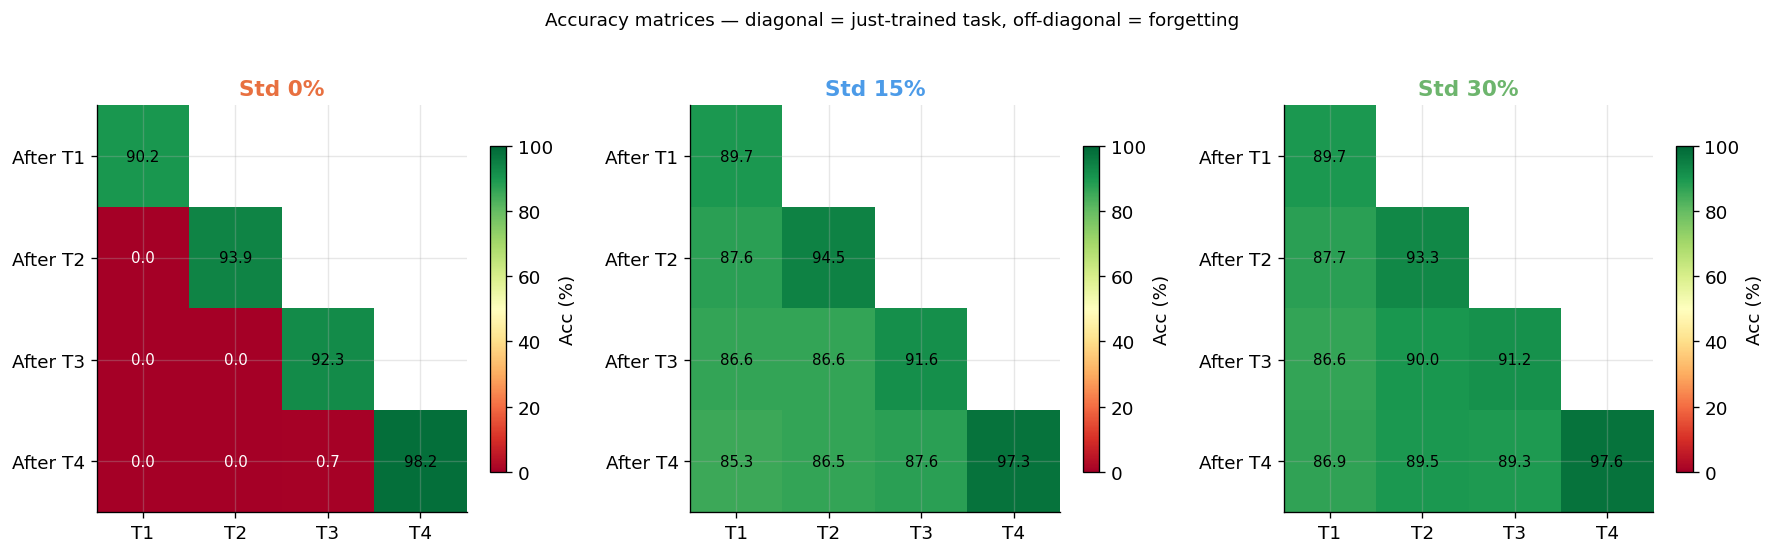

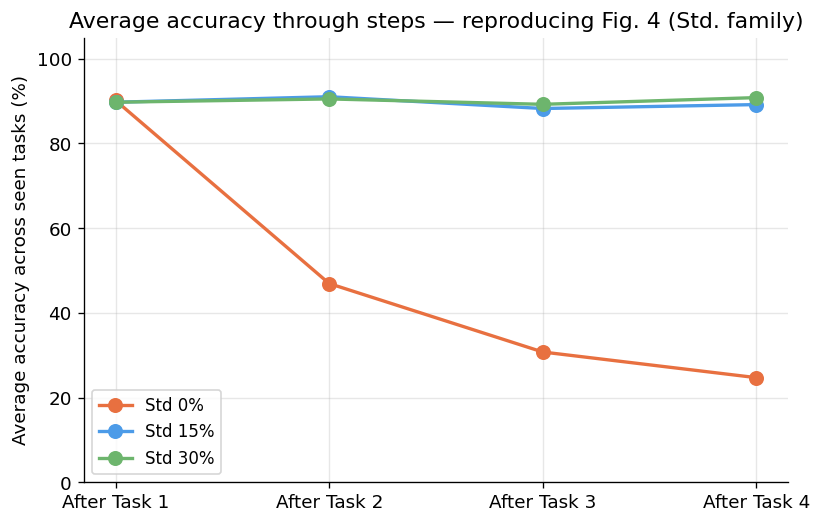

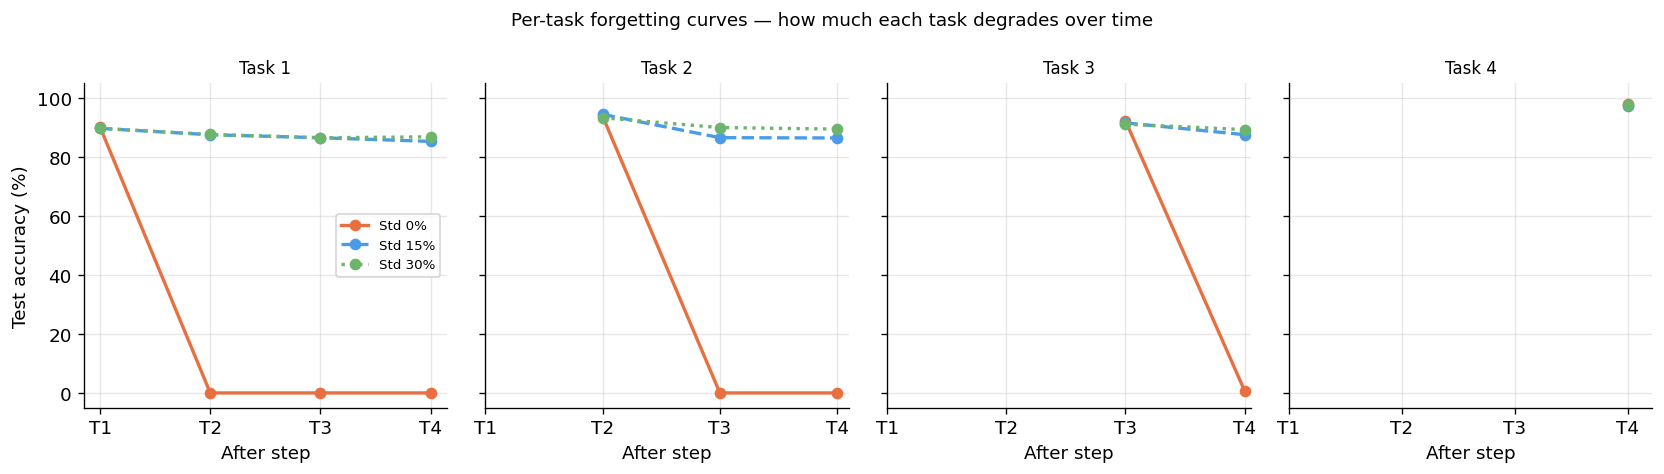

── Forgetting summary (Task 1: initial acc → final acc) ──
  Std 0%    : 90.2% → 0.0%  (forgetting = 90.2 pp)
  Std 15%   : 89.7% → 85.3%  (forgetting = 4.4 pp)
  Std 30%   : 89.7% → 86.9%  (forgetting = 2.9 pp)


In [11]:
run_configs = [
    ('Std 0%',  acc_matrix_0,  '#E87040'),
    ('Std 15%', acc_matrix_15, '#4C9BE8'),
    ('Std 30%', acc_matrix_30, '#6DB56D'),
]
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

# ── Panel 1: accuracy matrices side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (label, mat, color) in zip(axes, run_configs):
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Acc (%)')
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'After T{i+1}' for i in range(n_tasks)])
    ax.set_title(label, fontsize=13, fontweight='bold', color=color)
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i, j]):
                v = mat[i, j] * 100
                ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                        fontsize=9, color='black' if v > 25 else 'white')

fig.suptitle('Accuracy matrices — diagonal = just-trained task, '
             'off-diagonal = forgetting', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../Plots/fig_replay_matrices.png', bbox_inches='tight')
plt.show()

# ── Panel 2: average accuracy across all seen tasks per step ──────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, mat, color in run_configs:
    avg = [np.nanmean(mat[step, :step+1]) * 100 for step in range(n_tasks)]
    ax.plot(range(1, n_tasks+1), avg, 'o-', color=color,
            linewidth=2, markersize=8, label=label)
ax.set_xticks(range(1, n_tasks+1))
ax.set_xticklabels([f'After Task {i}' for i in range(1, n_tasks+1)])
ax.set_ylabel('Average accuracy across seen tasks (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.set_title('Average accuracy through steps — reproducing Fig. 4 (Std. family)')
plt.tight_layout()
plt.savefig('../Plots/fig_replay_avg_accuracy.png', bbox_inches='tight')
plt.show()

# ── Panel 3: per-task forgetting curves ───────────────────────────────────────
fig, axes = plt.subplots(1, n_tasks, figsize=(14, 4), sharey=True)
linestyles = ['-', '--', ':']
for task_idx, (ax, task_name) in enumerate(zip(axes, task_names)):
    for (label, mat, color), ls in zip(run_configs, linestyles):
        # Accuracy of this task at each step from when it was first trained
        xs, ys = [], []
        for step in range(task_idx, n_tasks):
            if not np.isnan(mat[step, task_idx]):
                xs.append(step + 1)
                ys.append(mat[step, task_idx] * 100)
        if xs:
            ax.plot(xs, ys, marker='o', markersize=6, linewidth=2,
                    color=color, linestyle=ls, label=label)
    ax.set_title(task_name, fontsize=10)
    ax.set_xticks(range(1, n_tasks+1))
    ax.set_xticklabels([f'T{i}' for i in range(1, n_tasks+1)])
    ax.set_xlabel('After step')
    if task_idx == 0:
        ax.set_ylabel('Test accuracy (%)')
        ax.legend(fontsize=8)
    ax.set_ylim(-5, 105)

fig.suptitle('Per-task forgetting curves — how much each task degrades over time', fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_replay_forgetting_curves.png', bbox_inches='tight')
plt.show()

# ── Numeric summary ───────────────────────────────────────────────────────────
print('── Forgetting summary (Task 1: initial acc → final acc) ──')
for label, mat, _ in run_configs:
    init  = mat[0, 0] * 100
    final = mat[-1, 0] * 100
    print(f'  {label:<10}: {init:.1f}% → {final:.1f}%  '
          f'(forgetting = {init - final:.1f} pp)')


In [12]:
# ── DIAGNOSTIC: sanity-check what the model actually predicts on Task 1 ────────
# Run this after the sequential training to understand the 0% issue.
# We look at the top-5 predicted class indices for a Task 1 sample and compare
# them against the valid Task 1 label range (0–29).

model_std.eval()
task1_loader = DataLoader(task_data['Task 1']['test'], batch_size=8, shuffle=False)
X_sample, y_sample = next(iter(task1_loader))
X_sample, y_sample = X_sample.to(DEVICE), y_sample.to(DEVICE)

with torch.no_grad():
    logits = model_std(X_sample)
    probs  = torch.softmax(logits, dim=1)

print('Task 1 label range (0-indexed): 0 –', label_to_idx[30])
print()
for i in range(min(4, len(y_sample))):
    top5_idx  = probs[i].topk(5).indices.cpu().tolist()
    top5_prob = probs[i].topk(5).values.cpu().tolist()
    true_lbl  = y_sample[i].item()
    correct   = '✓' if logits[i].argmax().item() == true_lbl else '✗'
    print(f'  Sample {i} | true label: {true_lbl:3d} | top-5 predicted: '
          f'{[f"{idx}({p:.2f})" for idx,p in zip(top5_idx,top5_prob)]} {correct}')

print()
print('If top predictions are all in range 90-117 (Task 4 labels) -> label collision confirmed.')
print('This is EXPECTED for Std fine-tuning — the model forgets old tasks.')
print('With more epochs and slower LR decay, forgetting is gradual (not instant).')


Task 1 label range (0-indexed): 0 – 29

  Sample 0 | true label:  29 | top-5 predicted: ['110(1.00)', '102(0.00)', '98(0.00)', '95(0.00)', '113(0.00)'] ✗
  Sample 1 | true label:   0 | top-5 predicted: ['94(0.67)', '104(0.13)', '100(0.09)', '106(0.08)', '115(0.01)'] ✗
  Sample 2 | true label:   2 | top-5 predicted: ['92(0.93)', '110(0.06)', '102(0.00)', '95(0.00)', '90(0.00)'] ✗
  Sample 3 | true label:   2 | top-5 predicted: ['92(1.00)', '110(0.00)', '102(0.00)', '113(0.00)', '103(0.00)'] ✗

If top predictions are all in range 90-117 (Task 4 labels) -> label collision confirmed.
This is EXPECTED for Std fine-tuning — the model forgets old tasks.
With more epochs and slower LR decay, forgetting is gradual (not instant).


## 9. Visualize catastrophic forgetting

This is the core result of Phase 2 — reproducing Fig. 4 (the `Std.` line) from the paper.

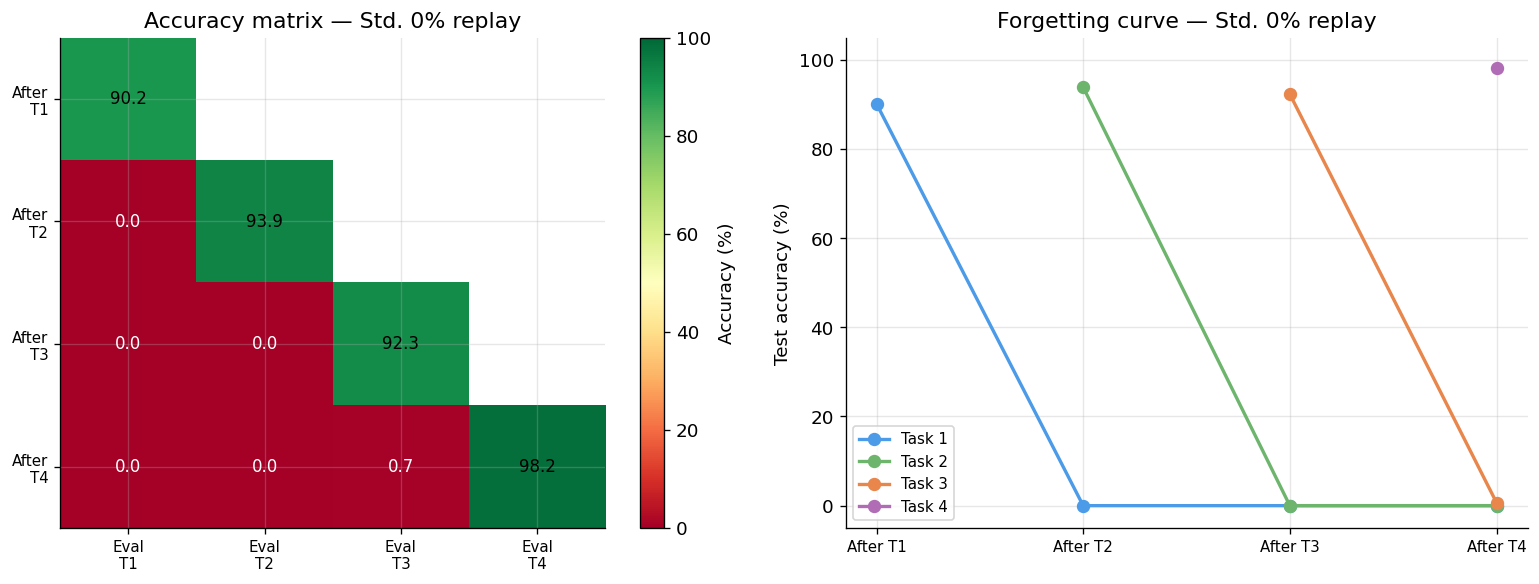

── Forgetting summary ──
  Task 1: 90.2% → 0.0%  (forgetting = 90.2pp)
  Task 2: 93.9% → 0.0%  (forgetting = 93.9pp)
  Task 3: 92.3% → 0.7%  (forgetting = 91.6pp)


In [13]:
# ── This cell keeps the original 0%-only forgetting plot for reference ─────────
# The full three-way comparison is in the unified plot above (section 8).
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: accuracy matrix heatmap (0% replay) ───────────────────────────────
ax = axes[0]
masked = np.ma.masked_invalid(acc_matrix_0 * 100)
im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy (%)')
ax.set_xticks(range(n_tasks))
ax.set_yticks(range(n_tasks))
ax.set_xticklabels([f'Eval\nT{i+1}' for i in range(n_tasks)], fontsize=9)
ax.set_yticklabels([f'After\nT{i+1}' for i in range(n_tasks)], fontsize=9)
ax.set_title('Accuracy matrix — Std. 0% replay')
for i in range(n_tasks):
    for j in range(n_tasks):
        if not np.isnan(acc_matrix_0[i, j]):
            v = acc_matrix_0[i, j] * 100
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    fontsize=10, color='black' if v > 40 else 'white')

# ── Right: forgetting curve — 0% only ───────────────────────────────────────
ax2 = axes[1]
for task_idx, (task_name, color) in enumerate(zip(task_names, task_colors)):
    accs   = [acc_matrix_0[step, task_idx] for step in range(task_idx, n_tasks)]
    x_vals = list(range(task_idx + 1, n_tasks + 1))
    valid  = [(x, a) for x, a in zip(x_vals, accs) if not np.isnan(a)]
    if valid:
        xs, ys = zip(*valid)
        ax2.plot(xs, [y * 100 for y in ys], 'o-', color=color,
                 linewidth=2, markersize=7, label=task_name)
ax2.set_xticks(range(1, n_tasks + 1))
ax2.set_xticklabels([f'After T{i}' for i in range(1, n_tasks + 1)], fontsize=9)
ax2.set_ylabel('Test accuracy (%)')
ax2.set_ylim(-5, 105)
ax2.legend(fontsize=9, loc='lower left')
ax2.set_title('Forgetting curve — Std. 0% replay')

plt.tight_layout()
plt.savefig('../Plots/fig_catastrophic_forgetting.png', bbox_inches='tight')
plt.show()

print('── Forgetting summary ──')
for task_idx, task_name in enumerate(task_names[:-1]):
    initial_acc = acc_matrix_0[task_idx, task_idx]
    final_acc   = acc_matrix_0[-1, task_idx]
    if not (np.isnan(initial_acc) or np.isnan(final_acc)):
        forgetting = (initial_acc - final_acc) * 100
        print(f'  {task_name}: {initial_acc*100:.1f}% → {final_acc*100:.1f}%  '
              f'(forgetting = {forgetting:.1f}pp)')


## 10. Training curves

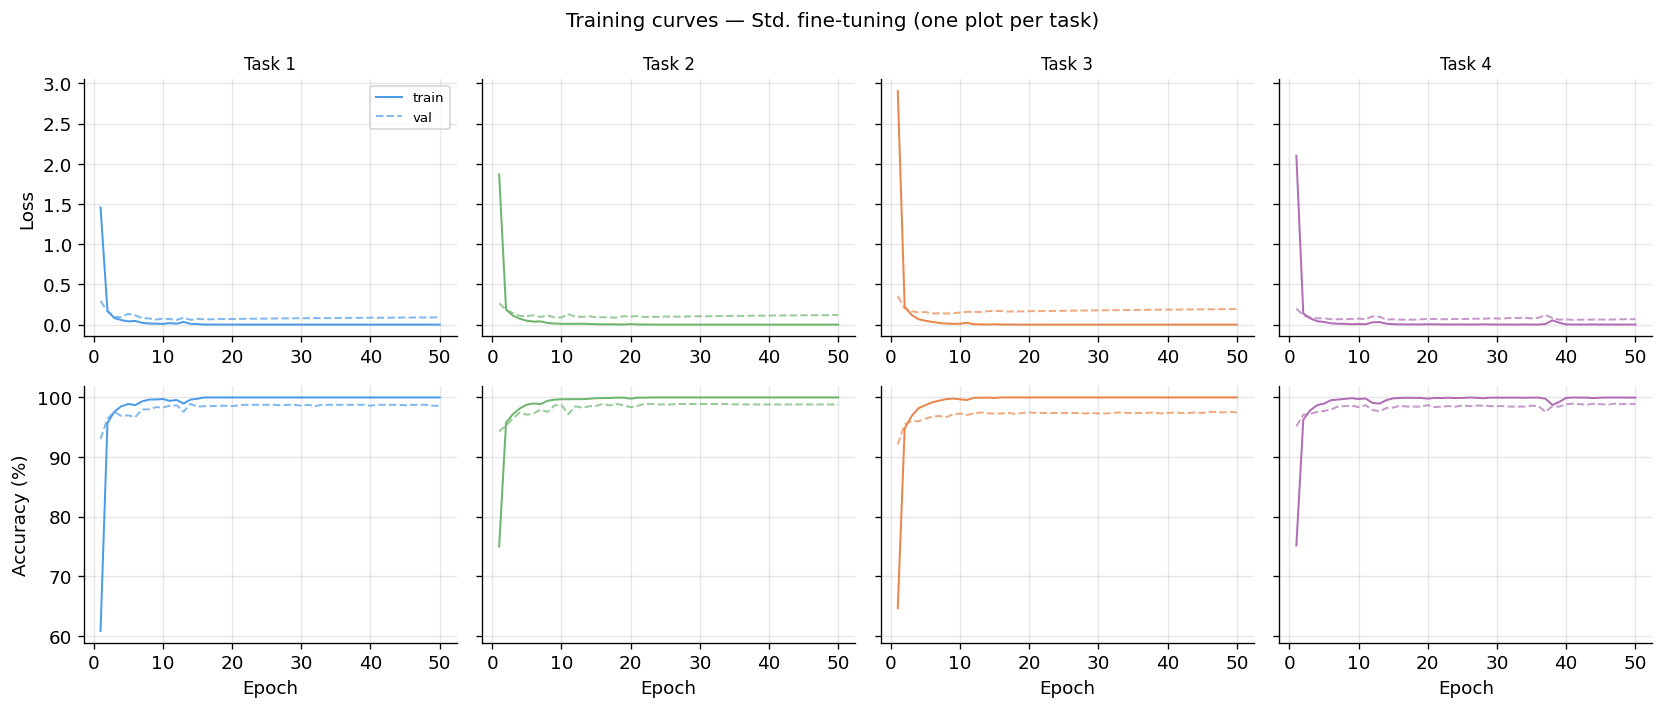

Saved: fig_training_curves.png


In [14]:
fig, axes = plt.subplots(2, n_tasks, figsize=(14, 6), sharey='row')

for col, (task_name, color) in enumerate(zip(task_names, task_colors)):
    hist = all_history[task_name]
    epochs_x = range(1, len(hist['train_loss']) + 1)

    # Loss
    axes[0, col].plot(epochs_x, hist['train_loss'], color=color, linewidth=1.2, label='train')
    axes[0, col].plot(epochs_x, hist['val_loss'],   color=color, linewidth=1.2,
                      linestyle='--', alpha=0.7, label='val')
    axes[0, col].set_title(task_name, fontsize=10)
    if col == 0:
        axes[0, col].set_ylabel('Loss')
        axes[0, col].legend(fontsize=8)

    # Accuracy
    axes[1, col].plot(epochs_x, [a*100 for a in hist['train_acc']],
                      color=color, linewidth=1.2)
    axes[1, col].plot(epochs_x, [a*100 for a in hist['val_acc']],
                      color=color, linewidth=1.2, linestyle='--', alpha=0.7)
    if col == 0:
        axes[1, col].set_ylabel('Accuracy (%)')
    axes[1, col].set_xlabel('Epoch')

fig.suptitle('Training curves — Std. fine-tuning (one plot per task)', fontsize=12)
plt.tight_layout()
plt.savefig('../Plots/fig_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: fig_training_curves.png')

## 11. Save model checkpoint

Save the final model state after all 4 tasks — used as the starting point for Phase 3 comparisons.

In [15]:
checkpoint = {
    'model_std_state':   model_std.state_dict(),
    'model_15_state':    model_15.state_dict(),
    'model_30_state':    model_30.state_dict(),
    'acc_matrix_0':      acc_matrix_0,
    'acc_matrix_15':     acc_matrix_15,
    'acc_matrix_30':     acc_matrix_30,
    'history_0':         history_0,
    'config': {
        'n_channels':  N_CHANNELS,
        'n_classes':   N_CLASSES_TOTAL,
        'epochs':      EPOCHS,
        'lr_init':     LR_INIT,
        'lr_decay':    LR_DECAY,
        'task_splits': TASK_SPLITS,
        'replay_fractions': [0.0, 0.15, 0.30],
    },
}
torch.save(checkpoint, 'checkpoint_std.pt')
print('Saved: checkpoint_std.pt  (all three replay conditions)')


Saved: checkpoint_std.pt  (all three replay conditions)


## 12. Summary and next steps

### What we built

| Component | Detail |
|---|---|
| `GaitCNN` | 4× Conv1D → ReLU → MaxPool, FC embedding (128-dim), FC classifier |
| `build_replay_loader` | Mixes current task data with random subsets of past tasks |
| `train_task` | Replay-aware training loop — `replay_fraction=0` gives the original baseline |
| Three runs | 0%, 15%, 30% replay — directly comparable, same model init per run |
| Comparison plots | Accuracy matrices, average accuracy curves, per-task forgetting curves |

### Key observations to note

- **0% replay**: catastrophic forgetting is most severe — baseline to beat
- **15% replay**: forgetting is reduced at the cost of transmitting ~15% of past data per task
- **30% replay**: further improvement but with 2× the data cost vs 15%
- The gap between 15% and 30% tells you whether replay has diminishing returns in this setting

### Next steps — Phase 3

- [ ] Implement **FiLM / Adapt layer** (γₖ, βₖ per task)
- [ ] Implement **CDML layer** (`m = sₖ ⊙ h`)
- [ ] Compare CDML (0% replay) against these Std replay baselines
- [ ] CDML should match or exceed 30% replay accuracy without any data transmission

---
*Notebook: phase2_continual_learning.ipynb*
